# Лабораторная 7

## 1. Построение описательный статистик двух финансовых активов

### Импорт библиотек:

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss, coint
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from arch import arch_model

### Загрузка исторических цен (закрытия на конец дня) и расчёт ежедневных доходностей

In [2]:
tickers = ['MSFT', 'AAPL']
start_date = '2020-01-01'
end_date = '2024-12-31'

data = yf.download(tickers, start=start_date, end=end_date)['Close']  # type: ignore
data.dropna(inplace=True)
returns = data.pct_change().dropna()

[*********************100%***********************]  2 of 2 completed


### Построение графика цен

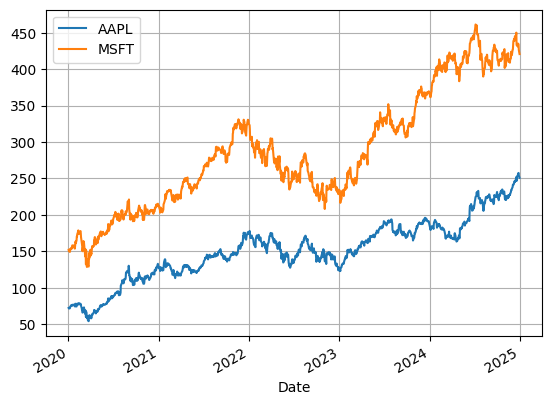

In [3]:
data.plot()
plt.grid()
plt.legend()
plt.show()

### Описательные статистики дневных доходностей

In [4]:
returns.describe()

Ticker,AAPL,MSFT
count,1256.000000,1256.000000
mean,0.001189,0.000995
std,0.019962,0.019217
min,-0.128647,-0.147390
25%,-0.008426,-0.008248
50%,0.001210,0.001113
75%,0.012017,0.010946
max,0.119808,0.142169


### Графики Бокса-Вискера дневных доходностей

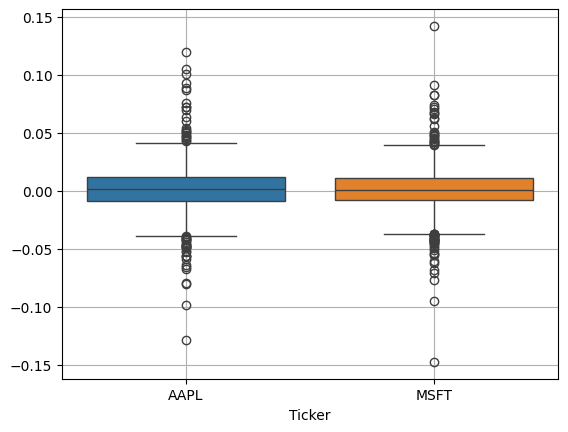

In [5]:
sns.boxplot(returns)
plt.grid()
plt.show()

### Гистограммы распределения дневных доходностей

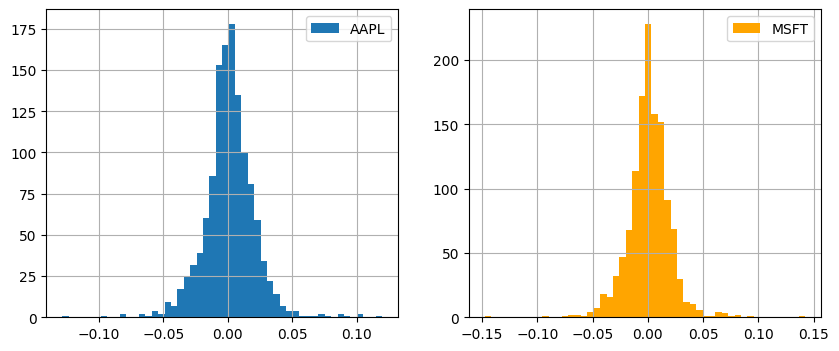

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,4))

ax1.hist(returns['AAPL'], bins=50, label='AAPL')
ax1.grid()
ax1.legend()

ax2.hist(returns['MSFT'], bins=50, color='orange', label='MSFT')
ax2.grid()
ax2.legend()

plt.show()

### График доходностей

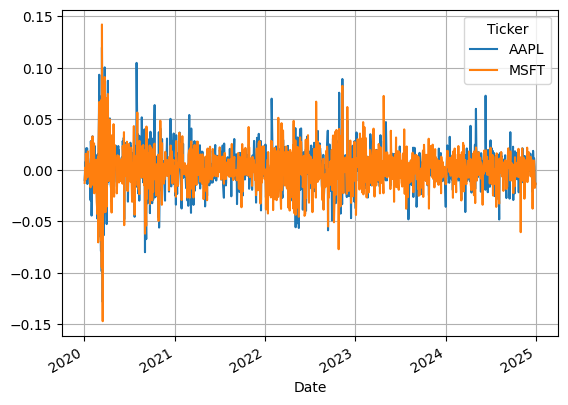

In [7]:
returns.plot()
plt.grid()
plt.show()

### Критерии стационарности ряда: ADF-test и KPSS-test

In [8]:
def adf_test(series, title=''):
    print(f'Augmented Dickey-Fuller Test ({title}):')
    result = adfuller(series.dropna(), autolag='AIC')
    print(f'ADF Statistic: {result[0]:.6f}')
    print(f'p-value: {result[1]:.6f}')
    print(f'Critical Values: {result[4]}')
    print('Reject H0 (Stationary)' if result[1] <= 0.05 else 'Fail to Reject H0 (Non-Stationary)')
    print('---')

def kpss_test(series, title=''):
    print(f'KPSS Test ({title}):')
    result = kpss(series.dropna(), regression='c', nlags='auto')
    print(f'KPSS Statistic: {result[0]:.6f}')
    print(f'p-value: {result[1]:.6f}')
    print(f'Critical Values: {result[3]}')
    print('Fail to Reject H0 (Stationary)' if result[1] <= 0.05 else 'Reject H0 (Non-Stationary)')
    print('---')

# Применяем тесты к доходностям
for ticker in tickers:
    adf_test(returns[ticker], title=ticker)
    kpss_test(returns[ticker], title=ticker)

Augmented Dickey-Fuller Test (MSFT):
ADF Statistic: -11.299805
p-value: 0.000000
Critical Values: {'1%': np.float64(-3.4356048614183443), '5%': np.float64(-2.8638605461891617), '10%': np.float64(-2.5680054872544145)}
Reject H0 (Stationary)
---
KPSS Test (MSFT):
KPSS Statistic: 0.095016
p-value: 0.100000
Critical Values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
Reject H0 (Non-Stationary)
---
Augmented Dickey-Fuller Test (AAPL):
ADF Statistic: -11.351127
p-value: 0.000000
Critical Values: {'1%': np.float64(-3.4356048614183443), '5%': np.float64(-2.8638605461891617), '10%': np.float64(-2.5680054872544145)}
Reject H0 (Stationary)
---
KPSS Test (AAPL):
KPSS Statistic: 0.108102
p-value: 0.100000
Critical Values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
Reject H0 (Non-Stationary)
---


/tmp/ipykernel_4062/3555273386.py:12: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(series.dropna(), regression='c', nlags='auto')
/tmp/ipykernel_4062/3555273386.py:12: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(series.dropna(), regression='c', nlags='auto')


### p-value обоих тестов близко к нулю, ряды стационарны. Значит, можно на их основе построить GARCH-модель

## 2. Построение модели GARCH(1,1) на основе случайных величин

Модель GARCH(1,1) (Generalized Autoregressive Conditional Heteroskedasticity) для временного ряда доходностей $r_t$ записывается как: $$\begin{gathered} r_t = \mu + \varepsilon_t, \\ \varepsilon_t=\sigma_t z_t, \\ \sigma^2_t=\omega + \alpha \varepsilon^2_{t-1} + \beta \sigma^2_{t-1} \end{gathered} $$  где $r_t$ - исследуемый ряд, $z_t$ - случайные величины, $\omega > 0$, $\alpha, \beta \ge 0$, $\alpha + \beta < 1$ (условие стационарности). $\mu$ задаётся в зависимости от центрированности ряда.
На реальных данных параметры чаще всего оцениваются методом максимального правдоподобия. Процесс $r_t$ должен быть процессом с условной гетероскедакстичностью, т. е. может быть представлен следующим образом $r_t = \sigma_t z_t$  

В рамках лабораторной работы для симуляции временных рядов и построения на них модели GARCH, зададим истинные значения $\omega, \alpha, \beta$ и построим ряды из приведённых формул, а затем оценим, как модель оценит эти параметры.

In [29]:
from typing import Tuple


def simulate_garch_process(omega: float, alpha: float, beta: float, T: int, distribution, *args):
    r = np.zeros(T)
    sigma2 = np.zeros(T)
    sigma2[0] = omega / (1 - alpha - beta)

    for t in range(1, T):
        sigma2[t] = omega + alpha * (r[t-1]**2) + beta * sigma2[t-1]
        r[t] = np.sqrt(sigma2[t]) * distribution(*args)

    return r, sigma2

omega = 0.1
alpha = 0.1
beta = 0.8
T = 1000

### Нормальное распределение

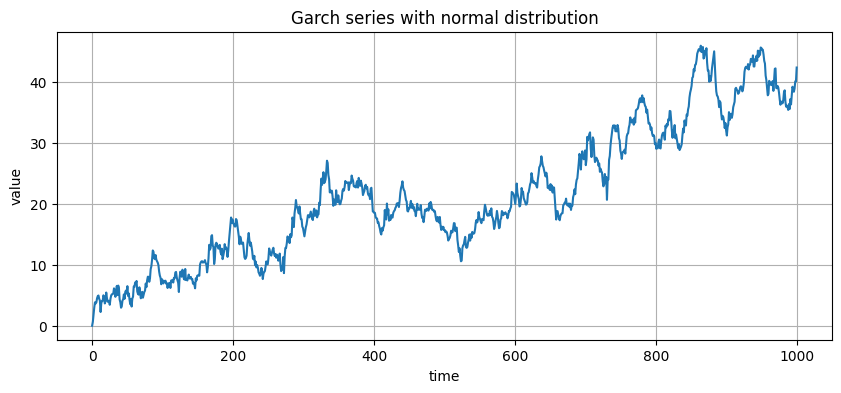

In [30]:
r_norm, sigma2_norm = simulate_garch_process(omega, alpha, beta, T, np.random.normal, 0, 1)

fig, ax = plt.subplots(1, 1, figsize=(10, 4))
plt.plot(np.cumsum(r_norm))
plt.title("Garch series with normal distribution")
plt.xlabel("time")
plt.ylabel("value")
plt.grid()
plt.show()

In [31]:
normal_model = arch_model(r_norm, vol="GARCH", p=1, q=1)
normal_model_fitted = normal_model.fit(disp="off")
normal_model_fitted.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                     Constant Mean - GARCH Model Results                      
==============================================================================
Dep. Variable:                      y   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -1339.84
Distribution:                  Normal   AIC:                           2687.68
Method:            Maximum Likelihood   BIC:                           2707.31
                                        No. Observations:                 1000
Date:                Mon, Apr 06 2026   Df Residuals:                      999
Time:                        11:23:15   Df Model:                            1
                                  Mean Model                                 
=============================================================================
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
mu             0.0395  2.884e-02      1.370      0.171 [-1.701e-02,9.604e-02]
                             Volatility Model                             
==========================================================================
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
omega          0.1344  6.456e-02      2.083  3.729e-02 [7.919e-03,  0.261]
alpha[1]       0.1071  3.365e-02      3.182  1.464e-03 [4.111e-02,  0.173]
beta[1]        0.7420  9.487e-02      7.821  5.230e-15   [  0.556,  0.928]
==========================================================================

Covariance estimator: robust
"""

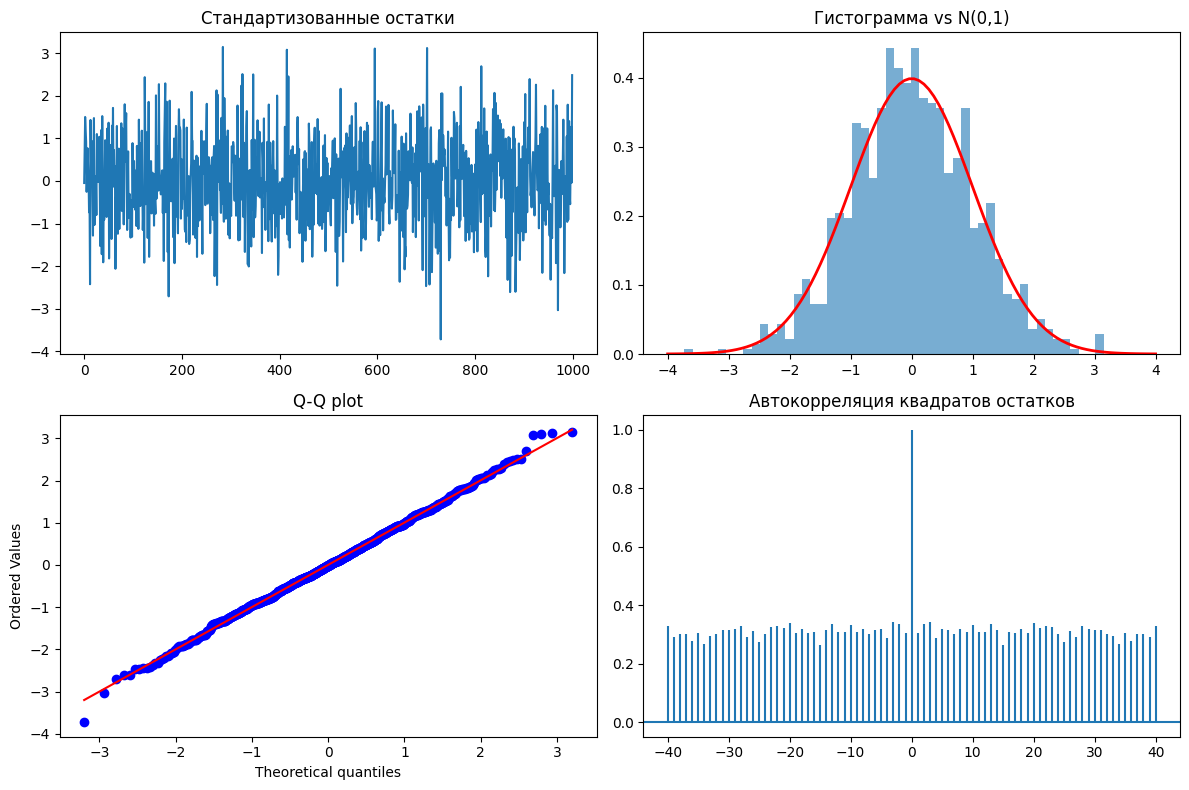

In [32]:
resid = normal_model_fitted.resid  # r_t
cond_vol = normal_model_fitted.conditional_volatility  # sigma_t
std_resid = resid / cond_vol

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0,0].plot(std_resid)
axes[0,0].set_title('Стандартизованные остатки')
axes[0,1].hist(std_resid, bins=50, density=True, alpha=0.6)
x = np.linspace(-4, 4, 100)
axes[0,1].plot(x, stats.norm.pdf(x), 'r-', lw=2, label='N(0,1)')
axes[0,1].set_title('Гистограмма vs N(0,1)')
stats.probplot(std_resid, dist='norm', plot=axes[1,0])
axes[1,0].set_title('Q-Q plot')
axes[1,1].acorr(std_resid**2, maxlags=40, usevlines=True, normed=True)
axes[1,1].set_title('Автокорреляция квадратов остатков')
plt.tight_layout()
plt.show()

#### Применим критерий Шапиро-Уилка для оценки, соответствуют ли остатки нормальному распределению.

In [33]:
sh_Stat, sh_pvalue = stats.shapiro(std_resid)
sh_pvalue

np.float64(0.7845213354948396)

In [34]:
train = r_norm[:800]
test = r_norm[800:]
model_train = arch_model(train, vol='GARCH', p=1, q=1)
res_train = model_train.fit(disp='off')
# Прогноз волатильности на 200 шагов вперёд (условной дисперсии)
forecast = res_train.forecast(horizon=200)
pred_vol_forecast = np.sqrt(forecast.variance.values[-1, :])  # прогнозные СКО

# Сравните с истинной волатильностью на тесте (если знаете)
true_vol_test = sigma2_norm[800:]  # из симуляции для индексов 800:1000
mse_forecast = np.mean((pred_vol_forecast - true_vol_test)**2)
print(f"Out-of-sample MSE прогноза волатильности: {mse_forecast:.4f}")

Out-of-sample MSE прогноза волатильности: 0.0630


### Variance Gamma

In [12]:
def vg_rvs(mu, theta, sigma, nu):
    """
    Генерация случайных чисел из VG распределения
    """
    # 1. Генерируем случайное время из гамма-распределения
    # Параметры: shape = 1/nu, scale = nu [citation:3]
    g = np.random.gamma(shape=1/nu, scale=nu)
    
    # 2. Условное нормальное распределение:
    # VG = theta * g + sigma * sqrt(g) * N(0,1)
    # где g - сгенерированное гамма-время
    normal = np.random.normal(0, 1)
    vg = theta * g + sigma * np.sqrt(g) * normal + mu
    
    return vg

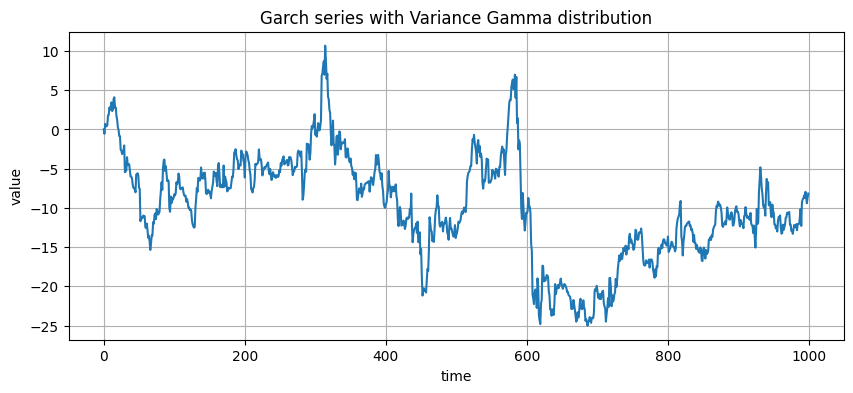

In [13]:
r_vg = simulate_garch_process(omega, alpha, beta, T, vg_rvs, 0, 0, 1, 1)

fig, ax = plt.subplots(1, 1, figsize=(10, 4))
plt.plot(np.cumsum(r_vg))
plt.title("Garch series with Variance Gamma distribution")
plt.xlabel("time")
plt.ylabel("value")
plt.grid()
plt.show()

In [16]:
vg_model = arch_model(r_vg, vol="GARCH", p=1, q=1)
vg_model_fitted = vg_model.fit(disp="off")
vg_model_fitted.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                     Constant Mean - GARCH Model Results                      
==============================================================================
Dep. Variable:                      y   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -1484.85
Distribution:                  Normal   AIC:                           2977.71
Method:            Maximum Likelihood   BIC:                           2997.34
                                        No. Observations:                 1000
Date:                Mon, Apr 06 2026   Df Residuals:                      999
Time:                        10:51:08   Df Model:                            1
                                  Mean Model                                 
=============================================================================
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
mu         2.8492e-03  3.280e-02  8.686e-02      0.931 [-6.144e-02,6.714e-02]
                             Volatility Model                             
==========================================================================
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
omega          0.0706  2.742e-02      2.575  1.004e-02 [1.686e-02,  0.124]
alpha[1]       0.0944  2.820e-02      3.346  8.191e-04 [3.910e-02,  0.150]
beta[1]        0.8520  4.092e-02     20.820  2.872e-96   [  0.772,  0.932]
==========================================================================

Covariance estimator: robust
"""

#### $\alpha$-устойчивое распределение

В качестве $\alpha$ выберем 1.9

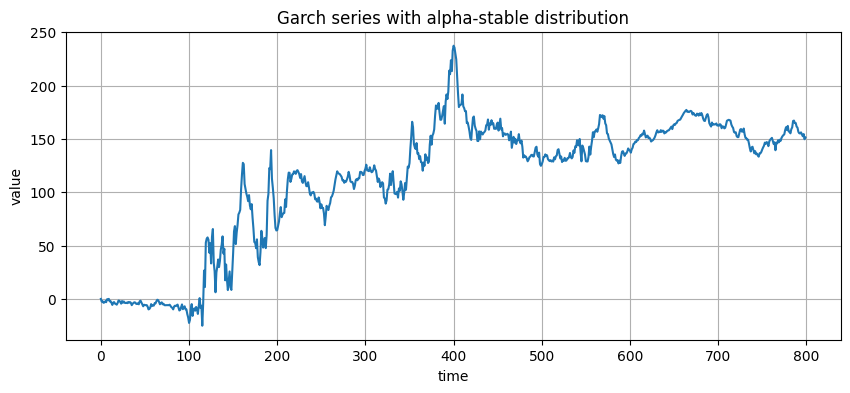

In [ ]:
r_alpha_stable = simulate_garch_process(omega, alpha, beta, 800, stats.levy_stable.rvs, 1.9, 0, 0, 1)

fig, ax = plt.subplots(1, 1, figsize=(10, 4))
plt.plot(np.cumsum(r_alpha_stable))
plt.title("Garch series with alpha-stable distribution")
plt.xlabel("time")
plt.ylabel("value")
plt.grid()
plt.show()

In [ ]:
as_model = arch_model(r_alpha_stable, vol="GARCH", p=1, q=1)
as_model_fitted = as_model.fit(disp="off")
as_model_fitted.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                     Constant Mean - GARCH Model Results                      
==============================================================================
Dep. Variable:                      y   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -2255.80
Distribution:                  Normal   AIC:                           4519.59
Method:            Maximum Likelihood   BIC:                           4538.33
                                        No. Observations:                  800
Date:                Sun, Apr 05 2026   Df Residuals:                      799
Time:                        23:48:26   Df Model:                            1
                               Mean Model                               
========================================================================
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
mu         1.1191e-03  9.444e-02  1.185e-02      0.991 [ -0.184,  0.186]
                             Volatility Model                             
==========================================================================
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
omega          0.1489  7.316e-02      2.035  4.180e-02 [5.524e-03,  0.292]
alpha[1]       0.1762  2.992e-02      5.890  3.867e-09   [  0.118,  0.235]
beta[1]        0.8238  2.933e-02     28.087 1.395e-173   [  0.766,  0.881]
==========================================================================

Covariance estimator: robust
"""

## 5. GARCH(1,1) на реальных данных

In [ ]:


returns_scaled = returns * 100
model = arch_model(returns_scaled['AAPL'])

In [ ]:
model_fitted = model.fit(disp='off')

In [ ]:
print(model_fitted.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                   AAPL   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -2507.20
Distribution:                  Normal   AIC:                           5022.39
Method:            Maximum Likelihood   BIC:                           5042.93
                                        No. Observations:                 1256
Date:                Sun, Apr 05 2026   Df Residuals:                     1255
Time:                        23:48:26   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.1592  5.124e-02      3.107  1.890e-03 [5.877e-0

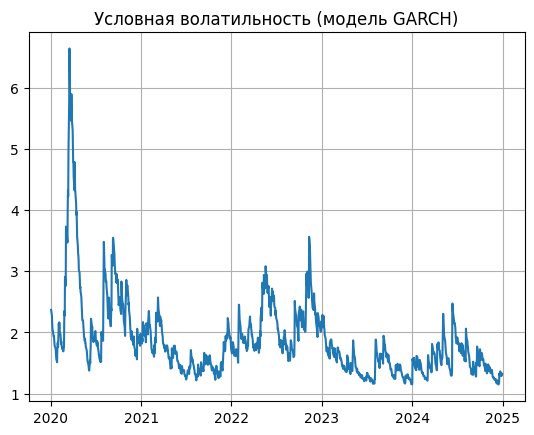

In [ ]:
conditional_volatility = model_fitted.conditional_volatility
plt.plot(conditional_volatility)
plt.title('Условная волатильность (модель GARCH)')
plt.grid()
plt.show()

In [ ]:
forecasts = model_fitted.forecast(horizon=5)
print("\nПрогноз дисперсии на 5 шагов:")
print(forecasts.variance.iloc[-1])


Прогноз дисперсии на 5 шагов:
h.1    1.848062
h.2    1.899603
h.3    1.949715
h.4    1.998438
h.5    2.045809
Name: 2024-12-30 00:00:00, dtype: float64


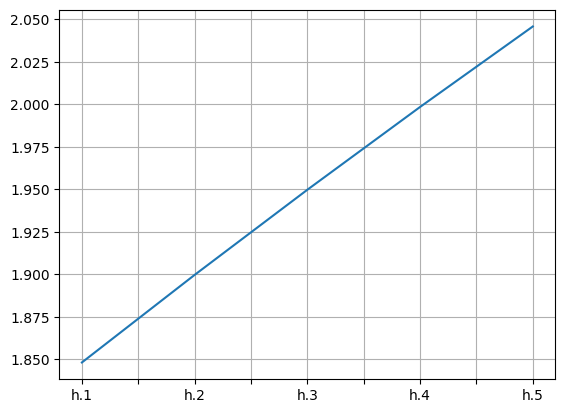

In [ ]:
forecasts.variance.iloc[-1].plot()
plt.grid()
plt.show()

In [ ]:
test_data = yf.download('AAPL', start='2025-01-01', end='2025-12-31')['Close']  # type: ignore
returns_test = test_data.pct_change().dropna()
test_data.head()

[*********************100%***********************]  1 of 1 completed


Ticker,AAPL
Date,
2025-01-02,242.525177
2025-01-03,242.037827
2025-01-06,243.668915
2025-01-07,240.894089
2025-01-08,241.381424


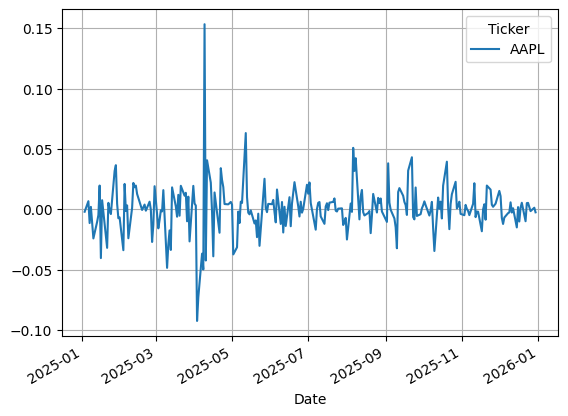

In [ ]:
returns_test.plot()
#forecasts.variance.iloc[-1].plot()
plt.grid()
plt.show()